In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("D:\Downloads\Project\Merge Dataset.csv")

In [3]:
df

,City,Hotel Name,Location,Distance,Rating,Review,No. of Reviews,Price
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ahmedabad,Taj Skyline,"Thaltej, Ahmedabad",10.3 km from centre,8.5,Very good,1045.0,8600.0
2,Ahmedabad,Four Points by Sheraton Ahmedabad,"Ellis Bridge, Ahmedabad",1.2 km from centre,8.2,Very good,615.0,7000.0
3,Ahmedabad,Artilla Inn,"Ellis Bridge, Ahmedabad (Ashram Road)",0.8 km from centre,8.1,Very good,811.0,4687.0
4,Ahmedabad,Le Meridien Ahmedabad,"SG Highway, Ahmedabad (SG Highway)",6.9 km from centre,7.8,Good,303.0,9000.0
...,...,...,...,...,...,...,...,...
1194,Pune,Teesta Suites,Pune,22.2 km from centre,9.2,Superb,19.0,2679.0
1195,Pune,Rutugandh Heritage,"Deccan, Pune",1.4 km from centre,6.1,Moderate,25.0,2100.0
1196,Pune,Hotel Royal Inn,Pune,10.1 km from centre,1.9,Moderate,8.0,899.0
1197,Pune,Treebo The Tree,"Pimpri, Pune (Hinjawadi)",19.7 km from centre,7.2,Good,34.0,2071.0


In [5]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [8]:
price_bins = [0, 2000, 4000, 6000, 8000, 10000, 15000, 20000]
price_labels = ['0–2k', '2–4k', '4–6k', '6–8k', '8–10k', '10–15k', '15k+']

df['Price_Bin'] = pd.cut(df['Price'], bins=price_bins, labels=price_labels, right=False)

In [9]:
price_dist = df['Price_Bin'].value_counts().sort_index()

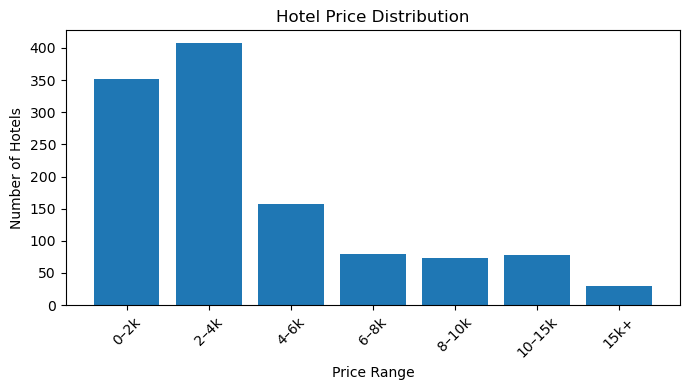

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(price_dist.index.astype(str), price_dist.values)
plt.title('Hotel Price Distribution')
plt.xlabel('Price Range')
plt.ylabel('Number of Hotels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

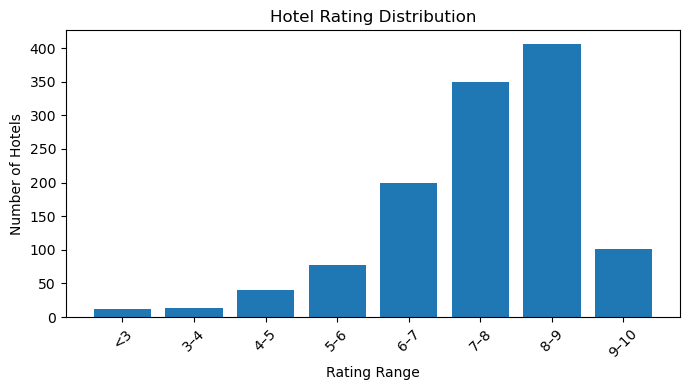

In [11]:
rating_bins = [0, 3, 4, 5, 6, 7, 8, 9, 10]
rating_labels = ['<3', '3–4', '4–5', '5–6', '6–7', '7–8', '8–9', '9–10']

df['Rating_Bin'] = pd.cut(df['Rating'], bins=rating_bins, labels=rating_labels)

rating_dist = df['Rating_Bin'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(rating_dist.index.astype(str), rating_dist.values)
plt.title('Hotel Rating Distribution')
plt.xlabel('Rating Range')
plt.ylabel('Number of Hotels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

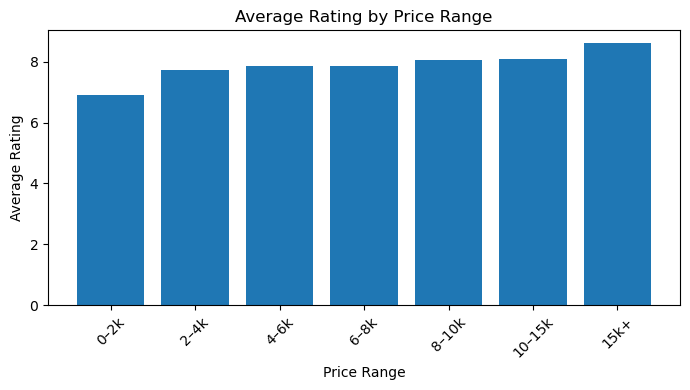

In [12]:
price_bins = [0, 2000, 4000, 6000, 8000, 10000, 15000, 20000]
price_labels = ['0–2k', '2–4k', '4–6k', '6–8k', '8–10k', '10–15k', '15k+']

df['Price_Bin'] = pd.cut(df['Price'], bins=price_bins, labels=price_labels, right=False)
price_rating = (
    df.groupby('Price_Bin', observed=True)['Rating']
      .mean()
      .reset_index()
)
plt.figure(figsize=(7,4))
plt.bar(price_rating['Price_Bin'].astype(str), price_rating['Rating'])
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()